In [25]:
import pandas as pd
df = pd.read_csv("Sample - Superstore.csv",encoding="latin1")

print(df.shape)
print(df.columns)
print(df.to_string())

(9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')
      Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID           Customer Name      Segment        Country               City                 State  Postal Code   Region       Product ID         Category Sub-Category                                                                                                                     Product Name       Sales  Quantity  Discount     Profit
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520             Claire Gute     Consumer  United States          Henderson              Kentucky        42420    South  FUR-BO-10001798        Furniture    Bookcases                      

In [26]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [27]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [28]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
print(df["Order Date"])

0      2016-11-08
1      2016-11-08
2      2016-06-12
3      2015-10-11
4      2015-10-11
          ...    
9989   2014-01-21
9990   2017-02-26
9991   2017-02-26
9992   2017-02-26
9993   2017-05-04
Name: Order Date, Length: 9994, dtype: datetime64[ns]


In [29]:
df["Month"] = df["Order Date"].dt.to_period("M")
print(df["Month"])

0       2016-11
1       2016-11
2       2016-06
3       2015-10
4       2015-10
         ...   
9989    2014-01
9990    2017-02
9991    2017-02
9992    2017-02
9993    2017-05
Name: Month, Length: 9994, dtype: period[M]


In [30]:
monthly_sales = df.groupby("Month")["Sales"].sum()

print(monthly_sales.to_string())

Month
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160
2017-

                    Sales       Profit
Segment                               
Consumer     1.161401e+06  134119.2092
Corporate    7.061464e+05   91979.1340
Home Office  4.296531e+05   60298.6785


<Axes: xlabel='Segment'>

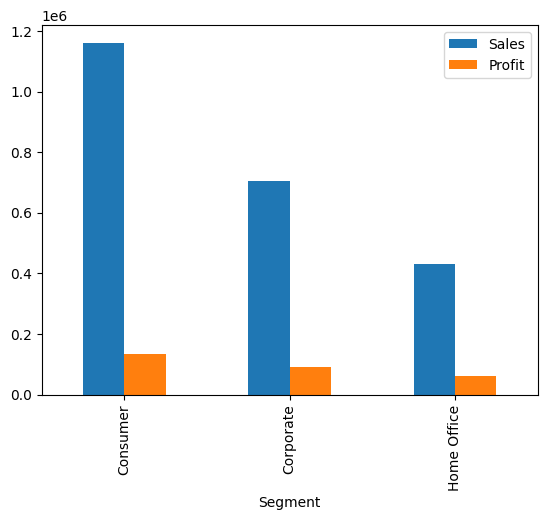

In [31]:
segment_sales =df.groupby("Segment")[["Sales","Profit"]].sum()
print(segment_sales)
segment_sales.plot(kind="bar")

In [32]:
region_profit = df.groupby("Region")["Profit"].sum()

print(region_profit)

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


In [33]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [34]:
category_profit = df.groupby('Category')['Profit'].sum()

print(category_profit)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


In [35]:
loss_subcat = (df.groupby("Sub-Category")["Profit"].sum(). sort_values())
print(loss_subcat)

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


In [36]:
state_sales=df.groupby("State")[["Sales","Profit"]].sum()
print(state_sales.sort_values("Sales",ascending=False))

                            Sales      Profit
State                                        
California            457687.6315  76381.3871
New York              310876.2710  74038.5486
Texas                 170188.0458 -25729.3563
Washington            138641.2700  33402.6517
Pennsylvania          116511.9140 -15559.9603
Florida                89473.7080  -3399.3017
Illinois               80166.1010 -12607.8870
Ohio                   78258.1360 -16971.3766
Michigan               76269.6140  24463.1876
Virginia               70636.7200  18597.9504
North Carolina         55603.1640  -7490.9122
Indiana                53555.3600  18382.9363
Georgia                49095.8400  16250.0433
Kentucky               36591.7500  11199.6966
New Jersey             35764.3120   9772.9138
Arizona                35282.0010  -3427.9246
Wisconsin              32114.6100   8401.8004
Colorado               32108.1180  -6527.8579
Tennessee              30661.8730  -5341.6936
Minnesota              29863.1500 

            Sales      Profit
Year                         
2014  484247.4981  49543.9741
2015  470532.5090  61618.6037
2016  609205.5980  81795.1743
2017  733215.2552  93439.2696

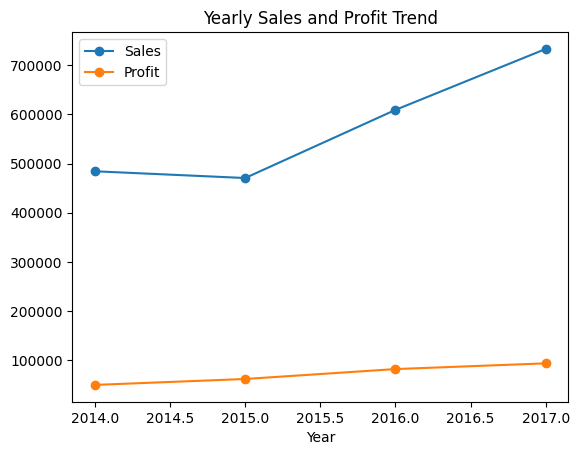

In [37]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Year"]=df["Order Date"].dt.year

yearly_sales=df.groupby("Year")[["Sales", "Profit"]].sum()
print(yearly_sales)
yearly_sales.plot(marker='o')
plt.title("Yearly Sales and Profit Trend")
plt.show()

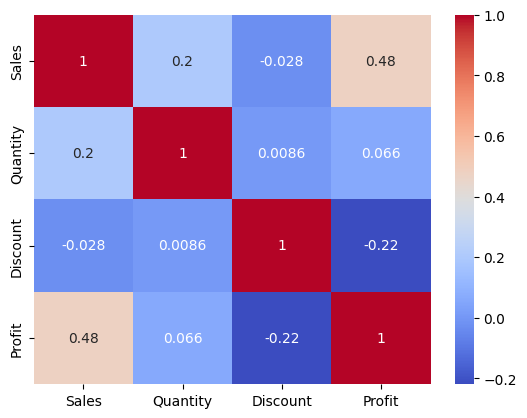

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(df[["Sales", "Quantity", "Discount", "Profit"]].corr(), annot=True, cmap="coolwarm")
plt.show()

In [39]:
print("Total Profit:", df["Profit"].sum())
print("Total Sales:", df["Sales"].sum())
print("Total Customers:", df["Customer ID"].nunique())
print("Total Order:", df["Order ID"].nunique())

Total Profit: 286397.0217
Total Sales: 2297200.8603
Total Customers: 793
Total Order: 5009
